## MLP Model

In [1]:
# import packages and dataset
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np
import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

url = "https://raw.githubusercontent.com/lwenqing090-web/traffic-signal-ml-project/refs/heads/main/data/cleansed_traffic_monitoring.csv"
df = pd.read_csv(url)

In [2]:
# use selected features
features = [
    'Traffic_Speed',
    'Road_Length',
    'Traffic_Volume',
    'Traffic_Density',
    'Signal_Phase_Duration',
    'Time_of_Day'
]

X = df[features]
y = df['Travel_Time']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
# build MLP model
mlp = MLPRegressor(
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

# define hyperparameter space
param_dist = {
    'hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.0001, 0.001, 0.01],
    'learning_rate_init': [0.001, 0.01],
    'batch_size': [64, 128, 256]
}

# randomized search
random_search = RandomizedSearchCV(
    estimator=mlp,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=MLPRegressor(early_stopping=True, max_iter=300,
                                          random_state=42),
                   n_jobs=-1,
                   param_distributions={'activation': ['relu', 'tanh'],
                                        'alpha': [0.0001, 0.001, 0.01],
                                        'batch_size': [64, 128, 256],
                                        'hidden_layer_sizes': [(32,), (64,),
                                                               (64, 32),
                                                               (128, 64)],
                                        'learning_rate_init': [0.001, 0.01]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [4]:
# find the best model
best_mlp = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV Score (negative MSE):")
print(random_search.best_score_)

# predict
y_pred_mlp = best_mlp.predict(X_test_scaled)

# evaluate model
mse_mlp = mean_squared_error(y_test, y_pred_mlp)
mae_mlp = mean_absolute_error(y_test, y_pred_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("\nTuned MLP Regressor Results")
print("Test MSE:", mse_mlp)
print("Test MAE:", mae_mlp)
print("Test R^2:", r2_mlp)

Best Parameters:
{'learning_rate_init': 0.01, 'hidden_layer_sizes': (32,), 'batch_size': 256, 'alpha': 0.01, 'activation': 'relu'}

Best CV Score (negative MSE):
-2.1631049798571227

Tuned MLP Regressor Results
Test MSE: 2.146296110036685
Test MAE: 1.2483647519783965
Test R^2: 0.9477953238920463


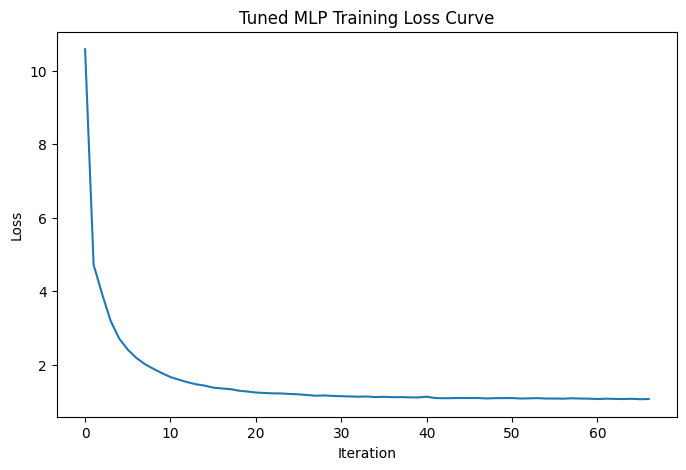

In [5]:
# visualization
# plot training loss curve
plt.figure(figsize=(8, 5))
plt.plot(best_mlp.loss_curve_)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Tuned MLP Training Loss Curve")
plt.show()

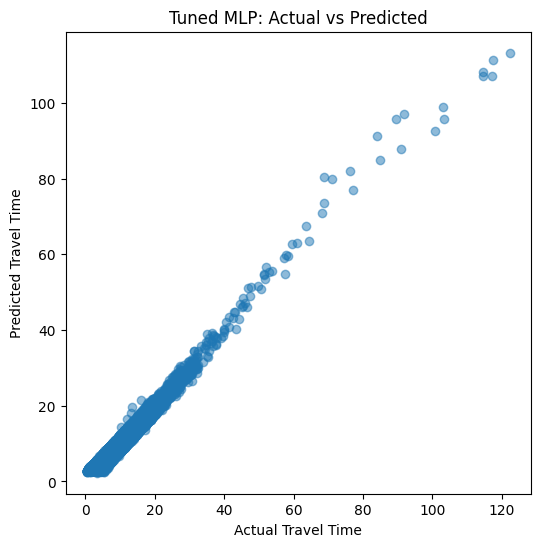

In [6]:
# plot Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_mlp, alpha=0.5)
plt.xlabel("Actual Travel Time")
plt.ylabel("Predicted Travel Time")
plt.title("Tuned MLP: Actual vs Predicted")
plt.show()

## Optimization

In [7]:
# choose one sample from the original dataframe
sample_idx = 0
sample = df.loc[sample_idx, features].copy()

# candidate signal phase durations to test
phase_candidates = np.arange(30, 181, 10)

results = []

for phase in phase_candidates:
    temp_sample = sample.copy()
    temp_sample['Signal_Phase_Duration'] = phase

    temp_df = pd.DataFrame([temp_sample], columns=features)
    temp_scaled = scaler.transform(temp_df)
    pred_time = best_mlp.predict(temp_scaled)[0]

    results.append({
        'Signal_Phase_Duration': phase,
        'Predicted_Travel_Time': pred_time
    })

results_df = pd.DataFrame(results)

# find the best phase
best_row = results_df.loc[results_df['Predicted_Travel_Time'].idxmin()]

print("Optimization result for one traffic condition:")
print(results_df)
print("\nBest signal phase duration:", best_row['Signal_Phase_Duration'])
print("Minimum predicted travel time:", best_row['Predicted_Travel_Time'])

Optimization result for one traffic condition:
    Signal_Phase_Duration  Predicted_Travel_Time
0                      30              12.130947
1                      40              12.115268
2                      50              12.099589
3                      60              12.083910
4                      70              12.068232
5                      80              12.052553
6                      90              12.036874
7                     100              12.021195
8                     110              12.005516
9                     120              11.989837
10                    130              11.974158
11                    140              11.958480
12                    150              11.942801
13                    160              11.927122
14                    170              11.911443
15                    180              11.899934

Best signal phase duration: 180.0
Minimum predicted travel time: 11.899933714995159


Predicted travel time under different signal phase durations for a fixed traffic condition. The minimum point indicates the optimal signal phase duration suggested by the tuned MLP model.

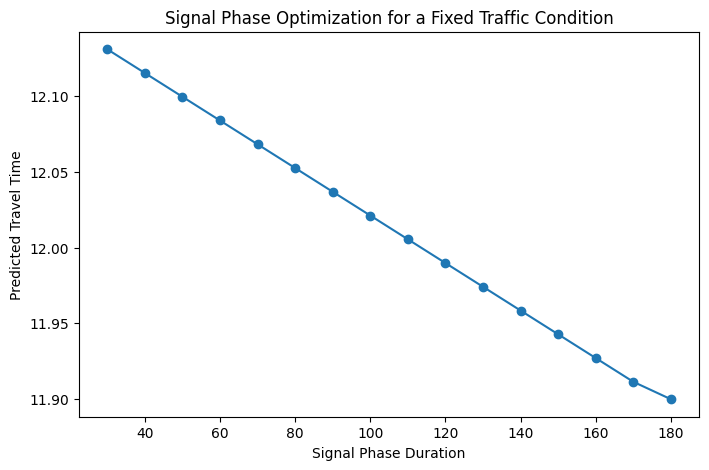

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(
    results_df['Signal_Phase_Duration'],
    results_df['Predicted_Travel_Time'],
    marker='o'
)
plt.xlabel("Signal Phase Duration")
plt.ylabel("Predicted Travel Time")
plt.title("Signal Phase Optimization for a Fixed Traffic Condition")
plt.show()

In [9]:
# find optimal signal phase durations across multiple traffic samples
n_samples = 100
test_subset = X_test.iloc[:n_samples].copy()

phase_candidates = np.arange(30, 181, 10)
all_best_phases = []
all_best_times = []

for i in range(len(test_subset)):
    base_sample = test_subset.iloc[i].copy()
    sample_results = []

    for phase in phase_candidates:
        temp_sample = base_sample.copy()
        temp_sample['Signal_Phase_Duration'] = phase

        temp_df = pd.DataFrame([temp_sample], columns=features)
        temp_scaled = scaler.transform(temp_df)
        pred_time = best_mlp.predict(temp_scaled)[0]

        sample_results.append((phase, pred_time))

    sample_results_df = pd.DataFrame(
        sample_results,
        columns=['Signal_Phase_Duration', 'Predicted_Travel_Time']
    )

    best_row = sample_results_df.loc[sample_results_df['Predicted_Travel_Time'].idxmin()]
    all_best_phases.append(best_row['Signal_Phase_Duration'])
    all_best_times.append(best_row['Predicted_Travel_Time'])

summary_df = pd.DataFrame({
    'Best_Phase': all_best_phases,
    'Best_Predicted_Travel_Time': all_best_times
})

print(summary_df.head())
print("\nAverage optimal phase:", summary_df['Best_Phase'].mean())
print("Most common optimal phase:", summary_df['Best_Phase'].mode()[0])
print("Average minimum predicted travel time:", summary_df['Best_Predicted_Travel_Time'].mean())

   Best_Phase  Best_Predicted_Travel_Time
0       180.0                    6.988868
1       140.0                   11.084153
2       140.0                    6.572710
3       180.0                    8.565511
4       180.0                   17.363427

Average optimal phase: 174.4
Most common optimal phase: 180.0
Average minimum predicted travel time: 9.344837702224792


Distribution of optimal signal phase durations across multiple traffic samples based on the tuned MLP model.

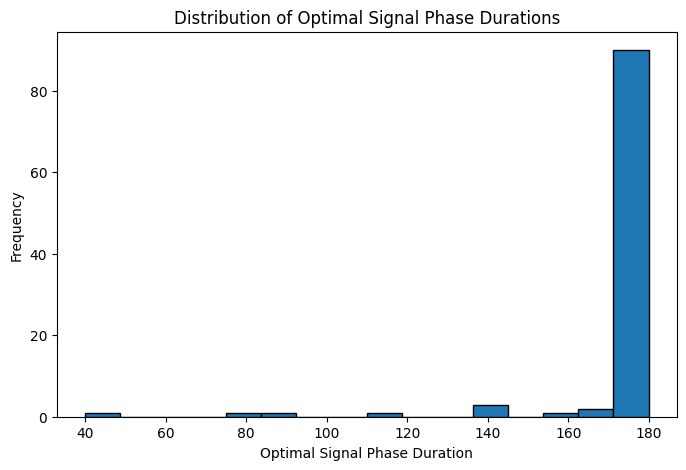

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(summary_df['Best_Phase'], bins=len(phase_candidates), edgecolor='black')
plt.xlabel("Optimal Signal Phase Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Optimal Signal Phase Durations")
plt.show()